# PKCERT Task 12 – Clustering & Dimensionality Reduction

**Objective:** Develop practical skills in unsupervised machine learning using clustering
algorithms and dimensionality reduction techniques.

**Dataset:** scikit-learn's built-in **Breast Cancer Wisconsin (Diagnostic)** dataset — the
same dataset reused across [Task_08](../Task_08)/[Task_09](../Task_09)/[Task_10](../Task_10)/
[Task_11](../Task_11), so this task can focus on the new unsupervised techniques rather than
re-justifying dataset choice. The key difference from those tasks: the diagnosis label is
**never used to fit** any model here (no supervised learning happens in this notebook) — it is
held out and only reintroduced at the very end, as an external check on whether clustering /
dimensionality reduction found structure that lines up with the real diagnosis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

import os
os.makedirs("visualizations", exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("scipy:", scipy.__version__)

numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2
scipy: 1.11.4


## Part A – Dataset Selection & Preparation (15 Marks)

### A.1 & A.2 Dataset Description

`sklearn.datasets.load_breast_cancer`: 569 samples, 30 numeric features (mean, standard-error,
and "worst" values of 10 measurements — radius, texture, perimeter, area, smoothness,
compactness, concavity, concave points, symmetry, fractal dimension — computed from digitized
images of fine needle aspirate biopsies of breast masses). A binary diagnosis label exists
(`0 = malignant`, `1 = benign`) but is **set aside** below — clustering and dimensionality
reduction are fit on the 30 features only, with the label reserved purely for evaluating,
after the fact, whether the unsupervised structure found lines up with the real diagnosis.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
y_true = data.target  # held out; NOT used to fit anything below

print("Shape:", df.shape)
print("\nMissing values total:", df.isna().sum().sum())
print("\nTrue diagnosis breakdown (held out, for later validation only):")
print(pd.Series(y_true).value_counts().rename(index={0: "malignant", 1: "benign"}))

df.describe().T[["mean", "std", "min", "max"]].head(8)

Shape: (569, 30)

Missing values total: 0

True diagnosis breakdown (held out, for later validation only):
benign       357
malignant    212
Name: count, dtype: int64


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.1100
mean texture,19.289649,4.301036,9.71000,39.2800
mean perimeter,91.969033,24.298981,43.79000,188.5000
mean area,654.889104,351.914129,143.50000,2501.0000
mean smoothness,0.096360,0.014064,0.05263,0.1634
mean compactness,0.104341,0.052813,0.01938,0.3454
mean concavity,0.088799,0.079720,0.00000,0.4268
mean concave points,0.048919,0.038803,0.00000,0.2012


### A.3 Preprocessing

- **Missing values** — none, no imputation needed.
- **Train/test split** — not used here. Clustering and dimensionality reduction are
  unsupervised, exploratory techniques fit on the whole dataset at once (there's no label to
  leak, and the goal is to describe the structure of *this* dataset, not to predict on unseen
  rows) — unlike Task_08–11's supervised models, which needed a held-out test set to estimate
  generalization.
- **Feature scaling** — both K-Means and hierarchical clustering are distance-based (they
  group points by Euclidean proximity), and PCA/t-SNE are both sensitive to feature variance,
  so features on a larger raw scale (e.g. `area`) would dominate purely due to units rather
  than genuine importance. `StandardScaler` is fit on all 30 features to zero mean / unit
  variance before any of the techniques below are applied.

In [3]:
X = df.values
feature_names = df.columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature means (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 4))
print("Scaled feature stds (should be ~1): ", np.round(X_scaled.std(axis=0)[:5], 4))

Scaled feature means (should be ~0): [-0. -0. -0. -0.  0.]
Scaled feature stds (should be ~1):  [1. 1. 1. 1. 1.]


## Part B – Clustering Techniques (45 Marks)

### B.1 K-Means — Choosing k

K-Means assigns each point to the nearest of `k` centroids, then repeatedly recomputes
centroids as the mean of their assigned points, until convergence. `k` isn't known in advance,
so it's chosen here by scanning `k = 2..10` and tracking two diagnostics:
- **Inertia** (within-cluster sum of squared distances) — the "elbow" method: it always
  decreases as `k` grows, so we look for where the rate of decrease flattens.
- **Silhouette score** (−1 to 1) — how well-separated and internally-cohesive the clusters
  are; unlike inertia it doesn't trivially improve with more clusters, so it directly identifies
  the best `k`, and is used as the deciding metric below.

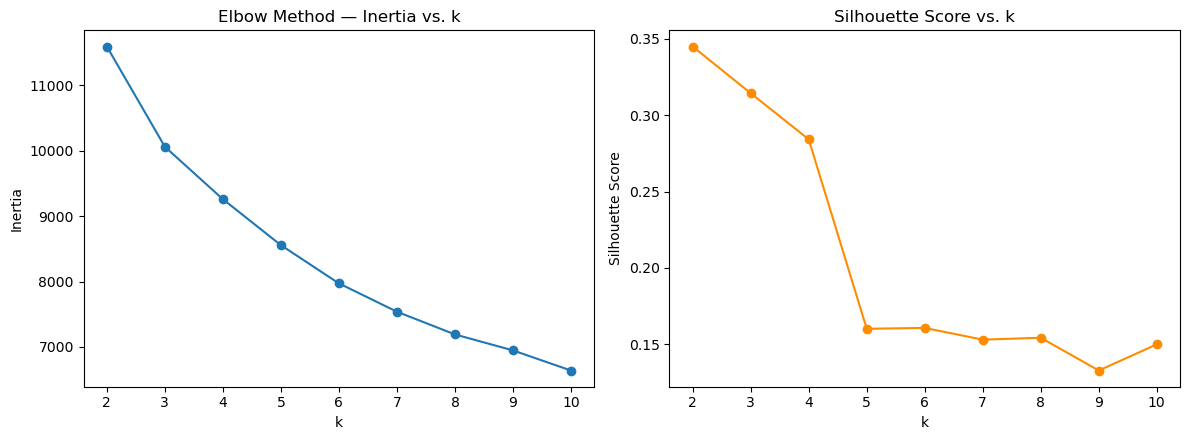

k= 2  inertia=  11595.5  silhouette=0.3450
k= 3  inertia=  10061.8  silhouette=0.3144
k= 4  inertia=   9259.5  silhouette=0.2842
k= 5  inertia=   8556.3  silhouette=0.1601
k= 6  inertia=   7971.5  silhouette=0.1607
k= 7  inertia=   7538.1  silhouette=0.1530
k= 8  inertia=   7190.7  silhouette=0.1542
k= 9  inertia=   6946.2  silhouette=0.1328
k=10  inertia=   6638.3  silhouette=0.1499


In [4]:
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method — Inertia vs. k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig("visualizations/1_kmeans_k_selection.png", dpi=150)
plt.show()

for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"k={k:2d}  inertia={i:9.1f}  silhouette={s:.4f}")

**Chosen k = 2.** The silhouette score peaks sharply at `k=2` (the elbow curve has no single
obvious bend, so silhouette is the deciding metric here, as planned above) — and this
matches the dataset's two known diagnosis classes, even though that label was never shown to
the algorithm.

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)

print("K-Means cluster sizes:", np.bincount(kmeans_labels))
print(f"K-Means silhouette score: {sil_kmeans:.4f}")

K-Means cluster sizes: [189 380]
K-Means silhouette score: 0.3450


### B.2 Hierarchical Clustering

Agglomerative (bottom-up) clustering: every point starts as its own cluster, and the two
closest clusters are merged repeatedly until one cluster remains, recorded as a merge tree
(the dendrogram). **Ward linkage** is used — it merges the pair of clusters that minimizes the
resulting increase in within-cluster variance, which pairs naturally with K-Means' own
variance-minimizing objective for a fair comparison.

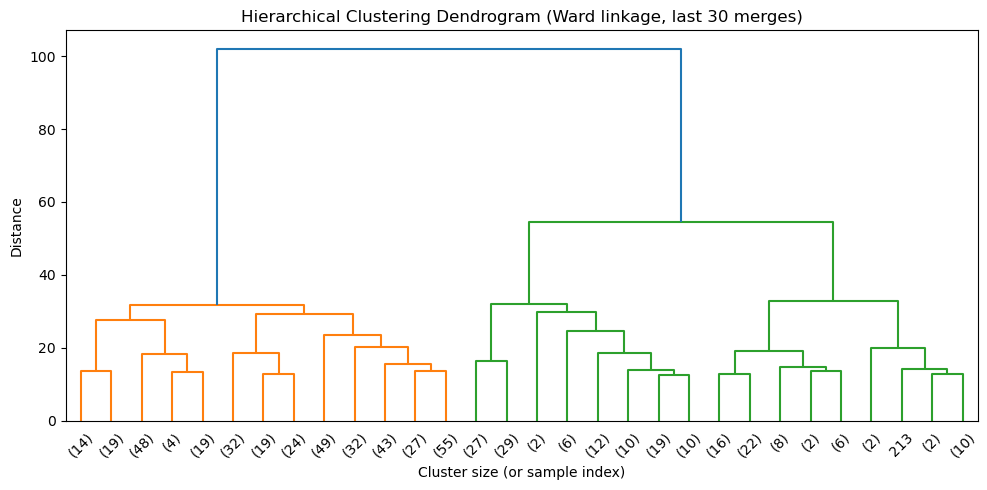

In [6]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, last 30 merges)")
plt.xlabel("Cluster size (or sample index)")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("visualizations/2_dendrogram.png", dpi=150)
plt.show()

In [7]:
hc = AgglomerativeClustering(n_clusters=2, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)
sil_hc = silhouette_score(X_scaled, hc_labels)

print("Hierarchical cluster sizes:", np.bincount(hc_labels))
print(f"Hierarchical silhouette score: {sil_hc:.4f}")

Hierarchical cluster sizes: [184 385]
Hierarchical silhouette score: 0.3394


### B.3 Comparing K-Means and Hierarchical Clustering

Cutting the dendrogram at 2 clusters (same `k` chosen for K-Means) gives a direct comparison.

In [8]:
ari_agreement = adjusted_rand_score(kmeans_labels, hc_labels)
print("Agreement between K-Means and Hierarchical (Adjusted Rand Index):", round(ari_agreement, 4))
print("\nCross-tab — K-Means cluster (rows) vs. Hierarchical cluster (columns):")
print(pd.crosstab(kmeans_labels, hc_labels, rownames=["KMeans"], colnames=["Hierarchical"]))

comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical (Ward)"],
    "Silhouette Score": [sil_kmeans, sil_hc],
    "Cluster Sizes": [tuple(np.bincount(kmeans_labels)), tuple(np.bincount(hc_labels))],
}).set_index("Method")
comparison

Agreement between K-Means and Hierarchical (Adjusted Rand Index): 0.8164

Cross-tab — K-Means cluster (rows) vs. Hierarchical cluster (columns):
Hierarchical    0    1
KMeans                
0             173   16
1              11  369


,Silhouette Score,Cluster Sizes
Method,,
K-Means,0.344974,"(189, 380)"
Hierarchical (Ward),0.339385,"(184, 385)"


**Observations:** The two methods agree strongly (ARI = 0.82 between their cluster
assignments) and land on almost identical cluster sizes. K-Means edges out Hierarchical on
silhouette score (0.345 vs. 0.339) — expected, since K-Means directly optimizes a
variance-based objective close to what silhouette rewards, while Ward linkage optimizes the
same objective only greedily/locally at each merge step rather than globally. For a dataset
this size (569 rows), both run in well under a second, so the real practical difference is
that Hierarchical additionally provides the full dendrogram (useful for exploring cluster
structure at *any* `k` without refitting) while K-Means requires picking `k` upfront but scales
far better to large `n` (Hierarchical clustering's O(n²) memory/distance-matrix requirement
becomes impractical well before K-Means' O(n·k·iterations) does).

## Part C – Dimensionality Reduction (30 Marks)

### C.1 PCA

PCA finds the orthogonal directions (principal components) of maximum variance in the scaled
feature space and projects the data onto the top few. It's linear, deterministic, and each
component's variance share is directly interpretable.

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.4f}")

pca_full = PCA(random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum_var >= 0.90) + 1)
n95 = int(np.argmax(cum_var >= 0.95) + 1)
print(f"Components needed for 90% variance: {n90}   |   for 95% variance: {n95}")

Explained variance ratio: [0.4427 0.1897]
Total variance captured by 2 components: 0.6324
Components needed for 90% variance: 7   |   for 95% variance: 10


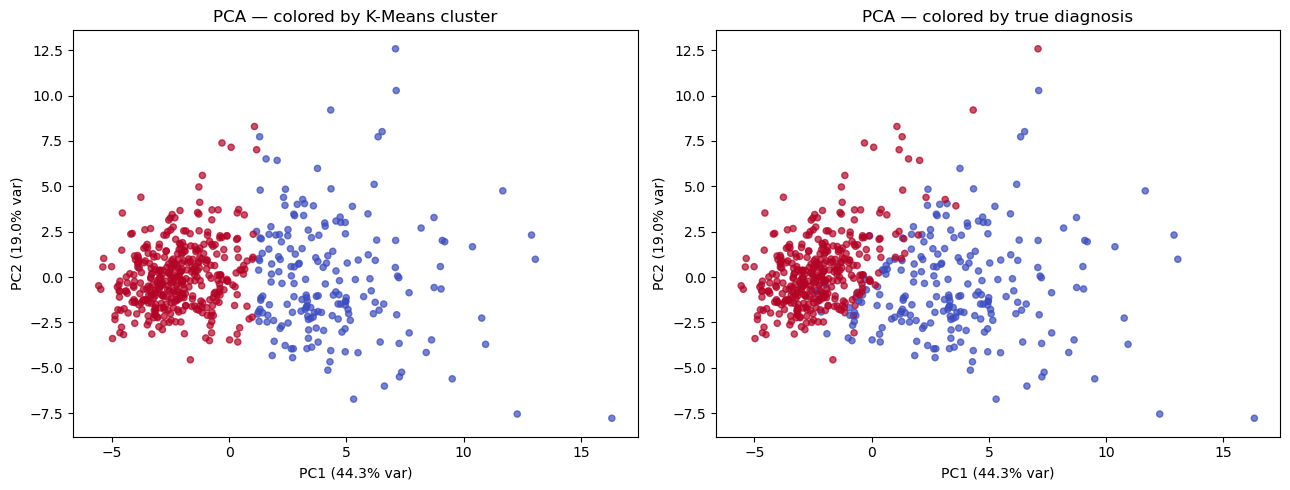

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, labels, title in [
    (axes[0], kmeans_labels, "PCA — colored by K-Means cluster"),
    (axes[1], y_true, "PCA — colored by true diagnosis"),
]:
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="coolwarm", alpha=0.7, s=20)
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.savefig("visualizations/3_pca_scatter.png", dpi=150)
plt.show()

Only **63.2%** of the total variance is captured in 2 components (44.3% + 19.0%) —
reaching 90% would need 7 components, and 95% would need 10. Even so, the 2D PCA projection
already visually separates the two diagnosis classes reasonably well, and the K-Means clusters
(left panel) closely track the true diagnosis pattern (right panel).

### C.2 t-SNE

t-SNE is a non-linear technique that models pairwise similarities between points as
probabilities (in both the original and low-dimensional space) and optimizes the low-dimensional
layout so those probability distributions match — it preserves local neighborhood structure
much more faithfully than a linear projection, at the cost of being stochastic and having no
direct interpretation for the resulting axes or inter-cluster distances.

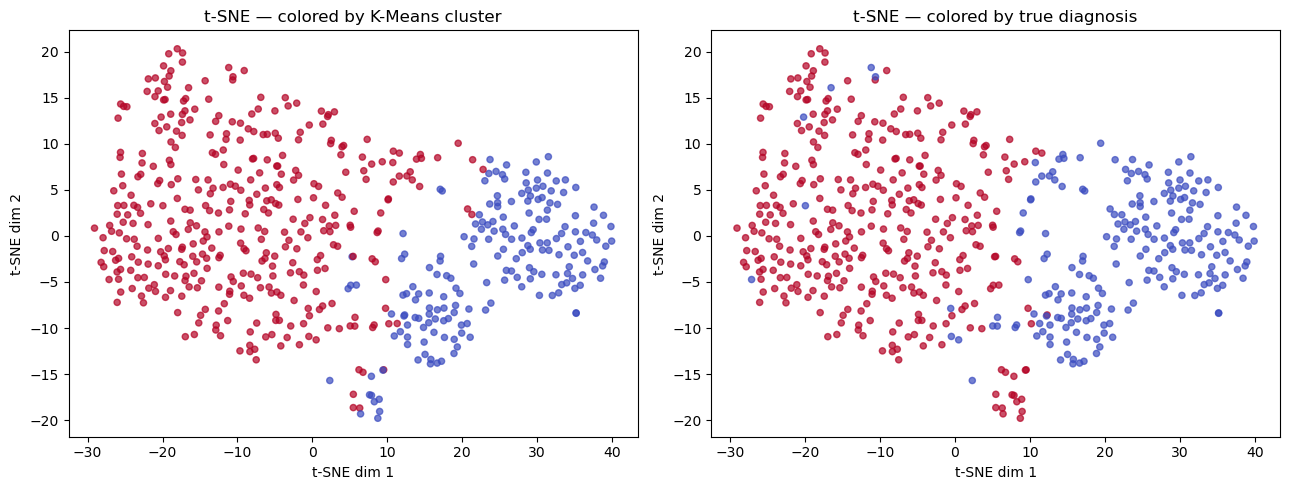

In [11]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, labels, title in [
    (axes[0], kmeans_labels, "t-SNE — colored by K-Means cluster"),
    (axes[1], y_true, "t-SNE — colored by true diagnosis"),
]:
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap="coolwarm", alpha=0.7, s=20)
    ax.set_title(title)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.savefig("visualizations/4_tsne_scatter.png", dpi=150)
plt.show()

In [12]:
sil_true_original = silhouette_score(X_scaled, y_true)
sil_true_pca = silhouette_score(X_pca, y_true)
sil_true_tsne = silhouette_score(X_tsne, y_true)

print("Silhouette score of the TRUE diagnosis labels, measured in each space:")
print(f"  Original scaled 30D space: {sil_true_original:.4f}")
print(f"  PCA 2D space:              {sil_true_pca:.4f}")
print(f"  t-SNE 2D space:            {sil_true_tsne:.4f}")

Silhouette score of the TRUE diagnosis labels, measured in each space:
  Original scaled 30D space: 0.2941
  PCA 2D space:              0.4377
  t-SNE 2D space:            0.4925


### C.3 PCA vs. t-SNE

Measuring the silhouette score of the **true diagnosis labels** in each space makes the
comparison concrete: 0.294 in the original 30D space, 0.438 after PCA, and 0.493 after t-SNE.
Both reductions make the two diagnosis classes look *more* separated than the raw feature space
does, and t-SNE's non-linear neighborhood-preserving embedding pulls them apart slightly more
than PCA's linear projection.

| | PCA | t-SNE |
|---|---|---|
| **Nature** | Linear projection onto directions of max variance | Non-linear, preserves local neighbor similarity |
| **Determinism** | Deterministic, same result every run | Stochastic — depends on random init/seed |
| **New data** | Has a `.transform()` — can project unseen points | No transform — must be refit on the full (old + new) data |
| **Interpretability** | Axes = ranked variance directions, loadings are meaningful | Axes have no meaning; only relative neighbor placement matters |
| **Global structure** | Preserves it (distances between far-apart points are meaningful) | Distorts it — only *local* neighborhoods are reliable, inter-cluster distances/densities are not |
| **Best use case** | Preprocessing before another model, quick interpretable summary, needs to generalize to new points | One-off, high-fidelity visual exploration of cluster separation |

**Recommendation for this dataset:** use PCA for anything downstream (e.g. as a
preprocessing step before another model, or to describe the data with fixed, reusable axes)
because it's deterministic and can transform new samples; use t-SNE specifically when the goal
is the clearest possible *visual* picture of how well-separated the clusters already are, which
is exactly what its higher silhouette score (0.493 vs. 0.438) demonstrates here.

## Part D – Analysis & Conclusion (10 Marks)

In [13]:
cluster_vs_true = pd.crosstab(kmeans_labels, y_true, rownames=["KMeans cluster"], colnames=["True diagnosis"])
cluster_vs_true.columns = ["malignant", "benign"]
ari_kmeans_true = adjusted_rand_score(y_true, kmeans_labels)
ari_hc_true = adjusted_rand_score(y_true, hc_labels)

print(cluster_vs_true)
print(f"\nAdjusted Rand Index, K-Means vs. true diagnosis:      {ari_kmeans_true:.4f}")
print(f"Adjusted Rand Index, Hierarchical vs. true diagnosis: {ari_hc_true:.4f}")

                malignant  benign
KMeans cluster                   
0                     175      14
1                      37     343

Adjusted Rand Index, K-Means vs. true diagnosis:      0.6707
Adjusted Rand Index, Hierarchical vs. true diagnosis: 0.5750


### D.1 Interpretation & Recommendation

Reintroducing the true diagnosis label (held out through every step above) for validation only:
K-Means' 2 clusters line up well with the real malignant/benign split — cluster 0 (189 points)
is 175/189 = **92.6% malignant**, cluster 1 (380 points) is 343/380 = **90.3% benign** — giving
an Adjusted Rand Index of **0.671** against the true labels, purely from unsupervised structure
in the 30 scaled features. Hierarchical clustering finds a similar but slightly less clean split
(ARI **0.575** vs. true labels, vs. K-Means' 0.671 — consistent with its slightly lower
silhouette score in Part B.3).

**Recommended techniques for this dataset:**
- **Clustering: K-Means (k=2)** — highest silhouette score (0.345) and highest agreement with
  the true diagnosis (ARI 0.671) of the two methods tried, at lower computational cost than
  Hierarchical for a dataset this size. Hierarchical remains a reasonable alternative if the
  dendrogram's multi-resolution view (inspecting structure at several `k` values without
  refitting) is itself valuable.
- **Dimensionality reduction: PCA for reuse, t-SNE for visualization** — PCA is recommended
  as the default because it's deterministic, has a real `.transform()` for scoring new patients,
  and its 2 components already recover 63.2% of total variance in an interpretable form. t-SNE
  is worth generating *in addition*, purely for visual inspection, since it shows marginally
  crisper class separation (silhouette 0.493 vs. PCA's 0.438) — but shouldn't replace PCA for
  any downstream numerical use, since its axes and inter-cluster distances carry no fixed
  meaning and it cannot be applied to new samples without a full refit.

Overall, this task shows that even with the diagnosis label completely hidden, K-Means +
PCA/t-SNE recover most of the real malignant/benign structure directly from the 30 measured
features — concrete evidence that the labeled dataset used for classification in
Task_08–11 has a genuinely learnable structure, not just a supervised signal grafted onto
otherwise-unstructured data.